In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("../data/raw/nasdaq100_fundamentals.csv")
df.head()

Matplotlib is building the font cache; this may take a moment.


,Ticker,Company,Sector,Industry,MarketCap,Revenue,NetIncome,FreeCashFlow,TotalDebt,Cash,PE_Ratio,EV_to_EBITDA,Price_to_Sales
0,NVDA,NVIDIA Corporation,Technology,Semiconductors,4534872047616,165217992704,86597001216,52436750336,1.059800e+10,5.679100e+10,53.217140,45.583,27.447810
1,AAPL,Apple Inc.,Technology,Consumer Electronics,3900351184896,408624988160,99280003072,94873747456,1.016980e+11,5.537200e+10,39.821213,27.853,9.545063
2,MSFT,Microsoft Corporation,Technology,Software - Infrastructure,3892038860800,281723994112,101831999488,61070376960,1.121840e+11,9.456500e+10,38.472446,24.978,13.815078
3,GOOGL,Alphabet Inc.,Communication Services,Internet Content & Information,3146676436992,371399000064,115572998144,49786499072,4.166800e+10,9.514800e+10,27.710022,21.940,8.472496
4,AMZN,"Amazon.com, Inc.",Consumer Cyclical,Internet Retail,2391180050432,670038032384,70623002624,31024001024,1.595700e+11,9.318000e+10,34.126330,18.363,3.568723


This is financial statement data from Yahoo Finance for the NASDAQ-100 companies. In order to do this, I hardcoded a list of 100 the NASDAQ-100 companies, listed as of 10/26 on stockanlysis.com.  I figured this would be an easier way to work with data by just picking a point in time.  I then got the data from the Yahoofinance library in python, which comes from the Yahoo finance website.  I then wrote the data frame to a csv to make the project easier to run and keep track of.  The dataset has things like revenue, net income, free cash flow, debt, cash, and ratios like P/E, EV/EBITDA, and P/S. My plan is to look at companies' profits, growth, debt, etc... relate to valuation of the stock, and see if there are differences across tech companies, retail etc. I then want to try building a model to predict valuation from the financial reportings.

In [2]:
# looking into dimentionality and issues/missing data
df.shape
#Theres 100 companies each having 13 variables that define them

(100, 13)

In [3]:
df.columns
df['Sector'].unique()
len(df['Industry'].unique())

44

We can see ticketer is the column with stock abbrevation of the companie.  The company is the company name, sector is the type of company each is and theres 11 categories that show up in this data set.  "In stocks, a sector is a broad, general category of the economy, while an industry is a more specific group of companies within that sector."  There are 44 industries present in this data.  Marketcap describes "Market capitalization, or market cap, is the total value of a company's shares of stock'.  PE_ratio "indicates how much investors are willing to pay for each dollar of a company's earnings and is used to determine if a stock is overvalued or undervalued."  EV_to_EBITDA "is a valuation metric that compares a company's total enterprise value to its earnings before interest, taxes, depreciation, and amortization (EBITDA). EV/EBITDA = Enterprise Value ÷ EBITDA , Enterprise Value (EV) ≈ MarketCap + Debt – Cash EBITDA ≈ Operating profit before depreciation & amortizatio It is used to determine if a company is overvalued or undervalued and helps in comparing companies across different industries by removing the effects of capital structure, taxes, and accounting policies."  Price to Sales is a "financial metric that compares a company's stock price to its revenue per share, indicating how much investors are willing to pay for each dollar of the company's sales. It is useful for valuing companies with low or negative earnings."  The combination of Market cap, ev to ebitda and price to sales are going to really help us define our valuation of a company.  

In [4]:
# check null values 
df.isnull().sum()
df[df.isnull().any(axis=1)]

,Ticker,Company,Sector,Industry,MarketCap,Revenue,NetIncome,FreeCashFlow,TotalDebt,Cash,PE_Ratio,EV_to_EBITDA,Price_to_Sales
23,INTU,Intuit Inc.,Technology,Software - Application,190448910336,18830999552,3868999936,5013875200,NaN,NaN,50.00659,NaN,10.113584
37,CRWD,"CrowdStrike Holdings, Inc.",Technology,Software - Infrastructure,132333666304,4341102080,-296985984,1443980160,8.105280e+08,4.972436e+09,NaN,-1403.178,30.483887
55,MRVL,"Marvell Technology, Inc.",Technology,Semiconductors,72528470016,7234899968,-103400000,1161250048,4.776300e+09,1.224400e+09,NaN,35.916,10.024806
71,ZS,"Zscaler, Inc.",Technology,Software - Infrastructure,51131162624,2673114880,-41478000,751312384,1.796576e+09,3.572409e+09,NaN,-634.689,19.127934
77,TTWO,"Take-Two Interactive Software, Inc.",Communication Services,Electronic Gaming & Multimedia,47062040576,5799199744,-4228800000,1226212480,3.506900e+09,2.035100e+09,NaN,80.795,8.115265
81,TEAM,Atlassian Corporation,Technology,Software - Application,42811944960,5215304192,-256687008,1661946240,1.239331e+09,2.937142e+09,NaN,-1077.630,8.208906
87,MCHP,Microchip Technology Incorporated,Technology,Semiconductors,34091565056,4235800064,-178400000,993012480,5.494500e+09,5.665000e+08,NaN,41.484,8.048436
91,KHC,The Kraft Heinz Company,Consumer Defensive,Packaged Foods,29885880320,25309999104,-5271000064,2745499904,2.121100e+10,2.564000e+09,NaN,7.758,1.180793
99,GFS,GlobalFoundries Inc.,Technology,Semiconductors,19601598464,6841999872,-115000000,1156749952,1.684000e+09,3.095000e+09,NaN,8.430,2.864893


In [5]:
# replace null values with 0, common to see zeros in these areas in finance 
df['TotalDebt'] = df['TotalDebt'].fillna(0)
df['Cash'] = df['Cash'].fillna(0)
df['PE_Ratio'] = df['PE_Ratio'].fillna(0)
df['EV_to_EBITDA'] = df['EV_to_EBITDA'].fillna(0)
df[df.isnull().any(axis=1)]
# no more null values!!!

,Ticker,Company,Sector,Industry,MarketCap,Revenue,NetIncome,FreeCashFlow,TotalDebt,Cash,PE_Ratio,EV_to_EBITDA,Price_to_Sales


In [6]:
#summary statistics
df.describe()

,MarketCap,Revenue,NetIncome,FreeCashFlow,TotalDebt,Cash,PE_Ratio,EV_to_EBITDA,Price_to_Sales
count,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,100.000000,100.000000,100.000000
mean,3.332381e+11,4.734245e+10,9.506468e+09,6.941031e+09,1.830715e+10,1.293380e+10,67.557062,29.199290,11.428567
std,8.155779e+11,1.004679e+11,2.340451e+10,1.577680e+10,2.868016e+10,4.192879e+10,149.870802,277.885212,22.108182
min,1.960160e+10,4.623220e+08,-5.271000e+09,-5.009500e+09,0.000000e+00,0.000000e+00,0.000000,-1403.178000,0.464272
25%,4.904090e+10,6.827250e+09,1.068275e+09,9.867281e+08,2.263750e+09,1.660675e+09,20.791260,12.740750,3.217998
50%,8.050222e+10,1.651250e+10,2.475553e+09,1.869406e+09,7.487924e+09,3.792008e+09,30.908223,19.990000,6.669108
75%,1.843758e+11,3.366300e+10,5.400608e+09,4.210402e+09,1.938200e+10,7.554250e+09,50.475707,33.512250,10.734435
max,4.534872e+12,6.700380e+11,1.155730e+11,9.487375e+10,1.595700e+11,3.871311e+11,1276.000000,1743.330000,179.522870


There are some outliers, especially just having a high sd and having a big range of values in the different variables. 
in this data especially it is important to understand that this will happen because a companies financials differ a lot.

In [7]:
df.dtypes

Ticker                str
Company               str
Sector                str
Industry              str
MarketCap           int64
Revenue             int64
NetIncome           int64
FreeCashFlow        int64
TotalDebt         float64
Cash              float64
PE_Ratio          float64
EV_to_EBITDA      float64
Price_to_Sales    float64
dtype: object

<Axes: xlabel='PE_Ratio', ylabel='Count'>

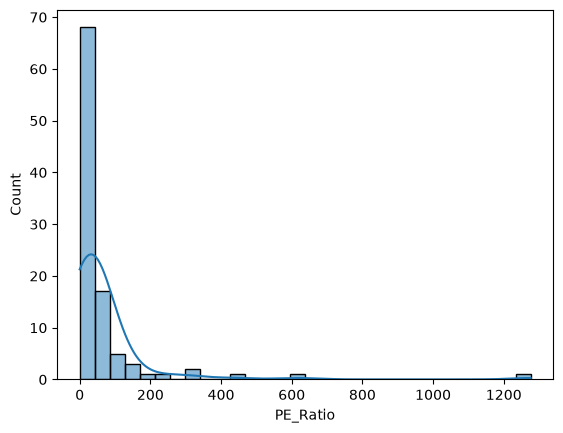

In [8]:
sns.histplot(data=df, x='PE_Ratio', bins=30, kde=True)

PE ratio has a heavily skewed right distribution, with a very long tail and an outlier at 1200. This tells me that log transforming PE_ratio will need to be done before moedling.  

<Axes: xlabel='PE_log', ylabel='Count'>

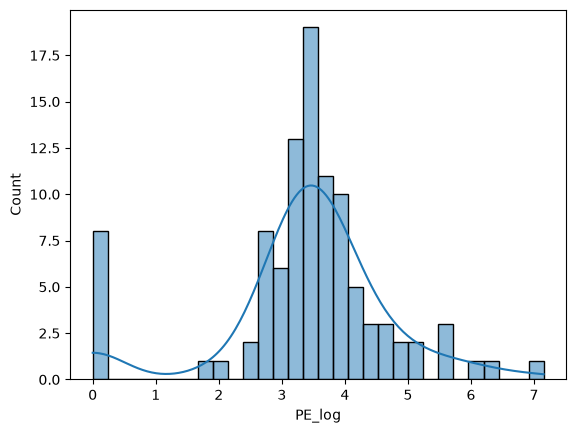

In [9]:
df['PE_log'] = np.log1p(df['PE_Ratio'])
sns.histplot(df['PE_log'], bins=30, kde=True)

<Axes: xlabel='MarketCap', ylabel='Count'>

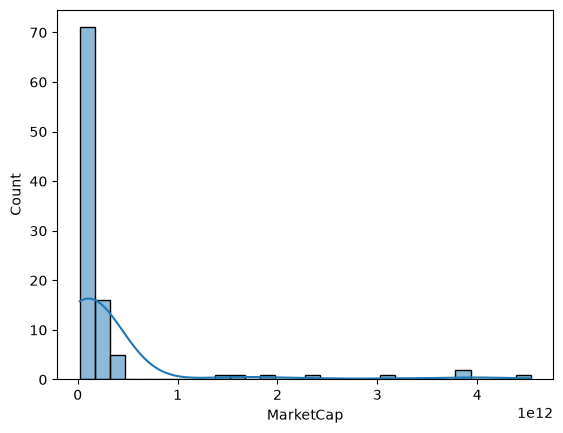

In [10]:
sns.histplot(data=df, x='MarketCap', bins=30, kde=True)

<Axes: xlabel='MarketCap_log', ylabel='Count'>

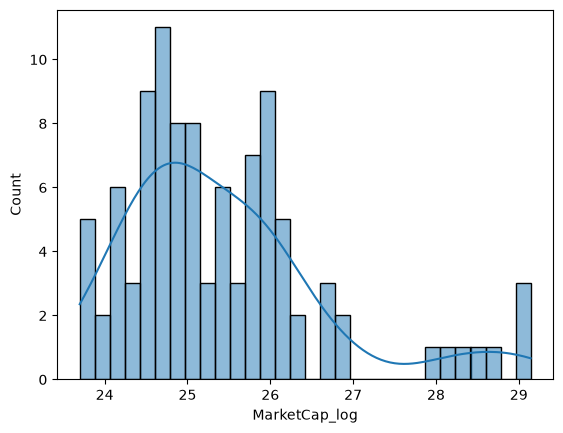

In [11]:
df['MarketCap_log'] = np.log1p(df['MarketCap'])
sns.histplot(df['MarketCap_log'], bins=30, kde=True)

<Axes: xlabel='Revenue', ylabel='Count'>

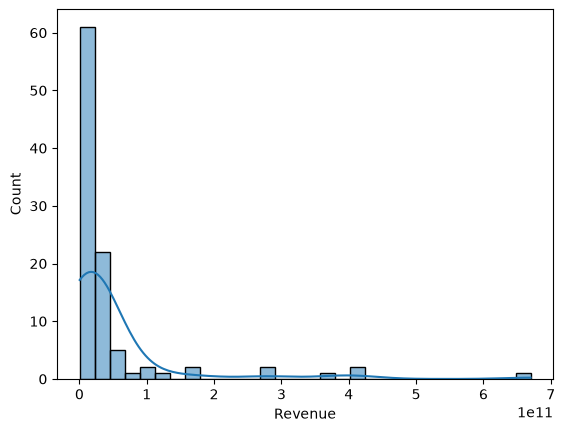

In [12]:
sns.histplot(data=df, x='Revenue', bins=30, kde=True)

<Axes: xlabel='Revenue_log', ylabel='Count'>

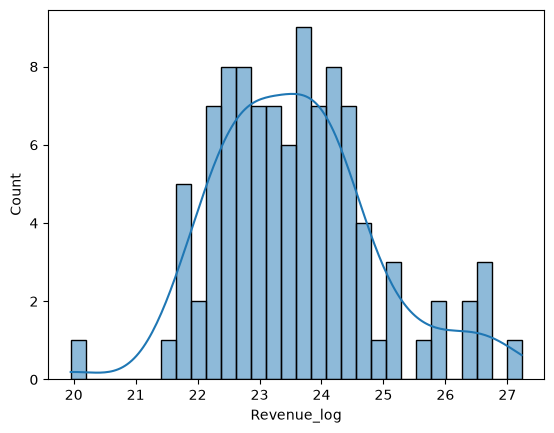

In [13]:
df['Revenue_log'] = np.log1p(df['Revenue'])
sns.histplot(df['Revenue_log'], bins=30, kde=True)

<Axes: xlabel='TotalDebt', ylabel='Count'>

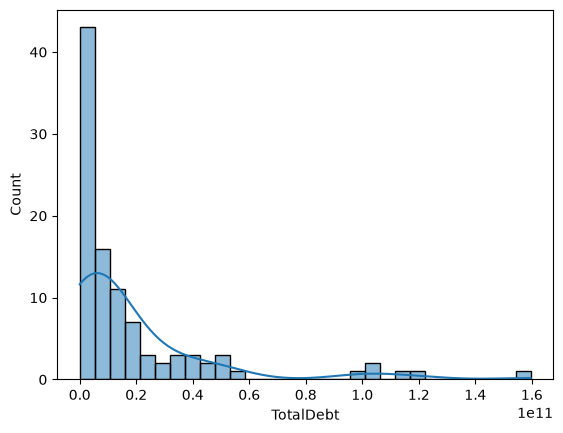

In [14]:
sns.histplot(data=df, x='TotalDebt', bins=30, kde=True)

<Axes: xlabel='TotalDebt_log', ylabel='Count'>

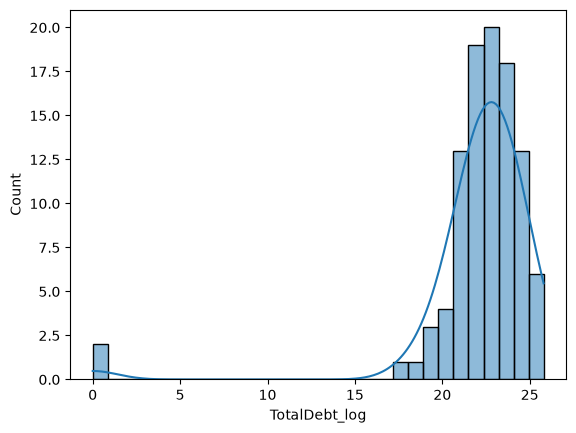

In [15]:
df['TotalDebt_log'] = np.log1p(df['TotalDebt'])
sns.histplot(df['TotalDebt_log'], bins=30, kde=True)

<Axes: xlabel='Cash', ylabel='Count'>

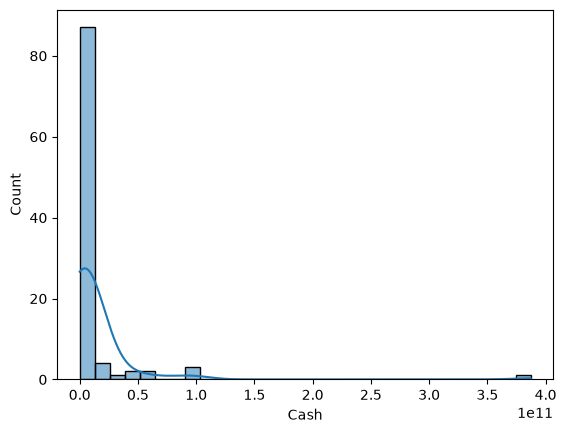

In [16]:
sns.histplot(data=df, x='Cash', bins=30, kde=True)

<Axes: xlabel='Cash_log', ylabel='Count'>

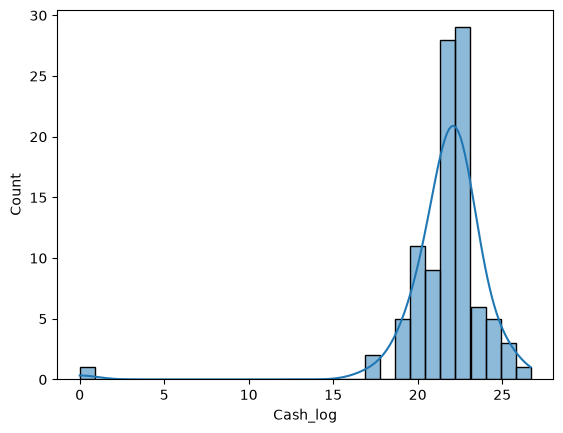

In [17]:
df['Cash_log'] = np.log1p(df['Cash'])
sns.histplot(df['Cash_log'], bins=30, kde=True)

<Axes: xlabel='Price_to_Sales', ylabel='Count'>

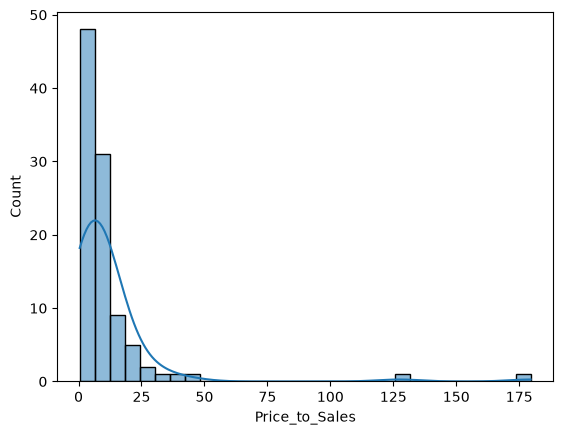

In [18]:
sns.histplot(data=df, x='Price_to_Sales', bins=30, kde=True)

<Axes: xlabel='Price_to_Sales_log', ylabel='Count'>

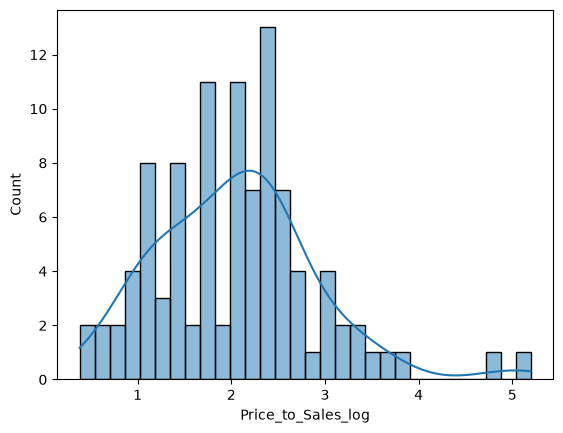

In [19]:
df['Price_to_Sales_log'] = np.log1p(df['Price_to_Sales'])
sns.histplot(df['Price_to_Sales_log'], bins=30, kde=True)

/Users/shannonmaccallum/Desktop/Project 2/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='NetIncome_log', ylabel='Count'>

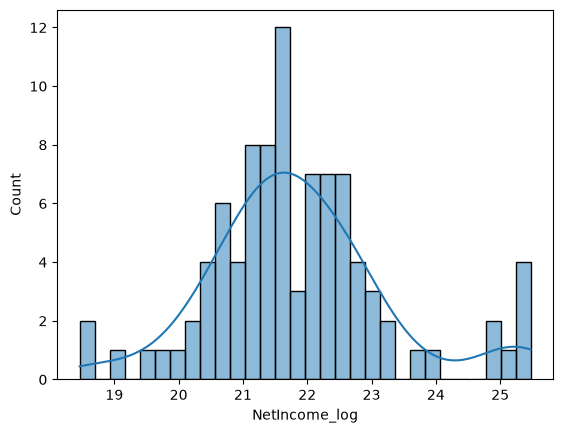

In [20]:
df['NetIncome_log'] = np.log1p(df['NetIncome'])
sns.histplot(df['NetIncome_log'], bins=30, kde=True)

<Axes: xlabel='FreeCashFlow', ylabel='Count'>

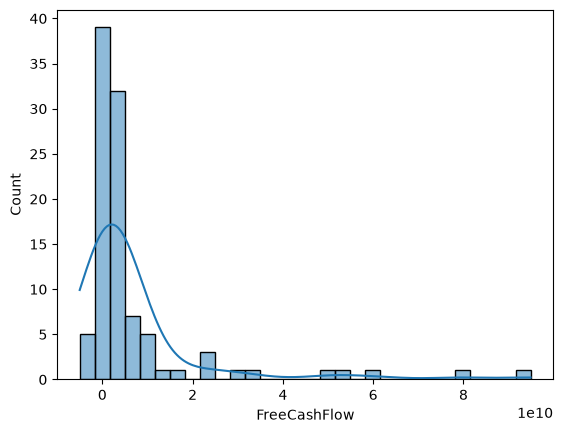

In [21]:
sns.histplot(data=df, x='FreeCashFlow', bins=30, kde=True)

<Axes: xlabel='EV_to_EBITDA', ylabel='Count'>

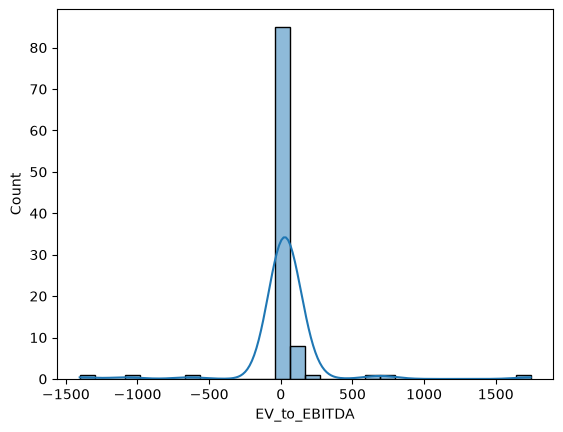

In [22]:
sns.histplot(data=df, x='EV_to_EBITDA', bins=30, kde=True)

<Axes: xlabel='NetIncome', ylabel='Count'>

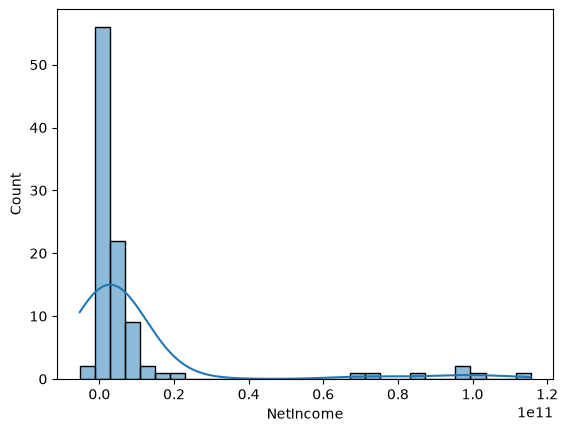

In [23]:
sns.histplot(data=df, x='NetIncome', bins=30, kde=True)

In [24]:
df[df['NetIncome'] < 0]

,Ticker,Company,Sector,Industry,MarketCap,Revenue,NetIncome,FreeCashFlow,TotalDebt,Cash,PE_Ratio,EV_to_EBITDA,Price_to_Sales,PE_log,MarketCap_log,Revenue_log,TotalDebt_log,Cash_log,Price_to_Sales_log,NetIncome_log
37,CRWD,"CrowdStrike Holdings, Inc.",Technology,Software - Infrastructure,132333666304,4341102080,-296985984,1443980160,8.105280e+08,4.972436e+09,0.0,-1403.178,30.483887,0.0,25.608592,22.191394,20.513196,22.327176,3.449476,NaN
55,MRVL,"Marvell Technology, Inc.",Technology,Semiconductors,72528470016,7234899968,-103400000,1161250048,4.776300e+09,1.224400e+09,0.0,35.916,10.024806,0.0,25.007245,22.702182,22.286932,20.925717,2.400148,NaN
71,ZS,"Zscaler, Inc.",Technology,Software - Infrastructure,51131162624,2673114880,-41478000,751312384,1.796576e+09,3.572409e+09,0.0,-634.689,19.127934,0.0,24.657660,21.706510,21.309148,21.996506,3.002109,NaN
77,TTWO,"Take-Two Interactive Software, Inc.",Communication Services,Electronic Gaming & Multimedia,47062040576,5799199744,-4228800000,1226212480,3.506900e+09,2.035100e+09,0.0,80.795,8.115265,0.0,24.574733,22.480986,21.977998,21.433811,2.209950,NaN
81,TEAM,Atlassian Corporation,Technology,Software - Application,42811944960,5215304192,-256687008,1661946240,1.239331e+09,2.937142e+09,0.0,-1077.630,8.208906,0.0,24.480083,22.374863,20.937838,21.800703,2.220171,NaN
87,MCHP,Microchip Technology Incorporated,Technology,Semiconductors,34091565056,4235800064,-178400000,993012480,5.494500e+09,5.665000e+08,0.0,41.484,8.048436,0.0,24.252316,22.166838,22.427013,20.154988,2.202592,NaN
91,KHC,The Kraft Heinz Company,Consumer Defensive,Packaged Foods,29885880320,25309999104,-5271000064,2745499904,2.121100e+10,2.564000e+09,0.0,7.758,1.180793,0.0,24.120652,23.954465,23.777786,21.664834,0.779689,NaN
99,GFS,GlobalFoundries Inc.,Technology,Semiconductors,19601598464,6841999872,-115000000,1156749952,1.684000e+09,3.095000e+09,0.0,8.430,2.864893,0.0,23.698877,22.646346,21.244438,21.853054,1.351934,NaN


In [25]:
df[df['FreeCashFlow'] < 0]

,Ticker,Company,Sector,Industry,MarketCap,Revenue,NetIncome,FreeCashFlow,TotalDebt,Cash,PE_Ratio,EV_to_EBITDA,Price_to_Sales,PE_log,MarketCap_log,Revenue_log,TotalDebt_log,Cash_log,Price_to_Sales_log,NetIncome_log
15,MU,"Micron Technology, Inc.",Technology,Semiconductors,245842526208,37377998848,8538999808,-891500032,1.535200e+10,1.030700e+10,28.818422,13.869,6.577198,3.395126,26.227957,24.344348,23.454512,23.056089,2.025144,22.867910
25,INTC,Intel Corporation,Technology,Semiconductors,182442475520,53439000576,198000000,-5009500160,4.655300e+10,3.093500e+10,1276.000000,20.971,3.414032,7.152269,25.929701,24.701807,24.563857,24.155154,1.484789,19.103778
32,TXN,Texas Instruments Incorporated,Technology,Semiconductors,153675415552,17265999872,5016000000,-684249984,1.404600e+10,5.186000e+09,30.750910,20.798,8.900464,3.457921,25.758109,23.572005,23.365604,22.369228,2.292582,22.335899
41,DASH,"DoorDash, Inc.",Consumer Cyclical,Internet Retail,110280335360,11895000064,781000000,-775750016,3.251000e+09,4.999000e+09,141.065570,130.141,9.271151,4.956289,25.426291,23.199384,21.902228,22.332504,2.329339,20.476086
42,MELI,"MercadoLibre, Inc.",Consumer Cyclical,Internet Retail,109562609664,24096000000,2052999936,-3821750016,9.010000e+09,3.983000e+09,53.479588,31.437,4.546921,3.997826,25.419762,23.905312,22.921601,22.105301,1.713243,21.442568
62,AEP,"American Electric Power Company, Inc.",Utilities,Utilities - Regulated Electric,62025498624,20666699776,3649700096,-4043899904,4.662460e+10,4.393000e+08,17.005865,12.751,3.001229,2.890698,24.850811,23.751790,24.565394,19.900693,1.386602,22.017911
75,EXC,Exelon Corporation,Utilities,Utilities - Regulated Electric,48514736128,23765999616,2654000128,-1859124992,4.885100e+10,7.240000e+08,18.264257,12.531,2.041351,2.958251,24.605133,23.891522,24.612041,20.400302,1.112302,21.699334
76,XEL,Xcel Energy Inc.,Utilities,Utilities - Regulated Electric,47544750080,13957000192,2072999936,-4188499968,3.338700e+10,1.465000e+09,22.268698,14.454,3.406516,3.147109,24.584937,23.359247,24.231432,21.105121,1.483084,21.452263
82,FANG,"Diamondback Energy, Inc.",Energy,Oil & Gas E&P,42224443392,13409999872,3816999936,-420249984,1.517900e+10,2.190000e+08,10.569565,6.276,3.148728,2.448378,24.466265,23.319267,23.443179,19.204582,1.422802,22.062731


In [26]:
df[df['EV_to_EBITDA'] < 0]

,Ticker,Company,Sector,Industry,MarketCap,Revenue,NetIncome,FreeCashFlow,TotalDebt,Cash,PE_Ratio,EV_to_EBITDA,Price_to_Sales,PE_log,MarketCap_log,Revenue_log,TotalDebt_log,Cash_log,Price_to_Sales_log,NetIncome_log
37,CRWD,"CrowdStrike Holdings, Inc.",Technology,Software - Infrastructure,132333666304,4341102080,-296985984,1443980160,8.105280e+08,4.972436e+09,0.0,-1403.178,30.483887,0.0,25.608592,22.191394,20.513196,22.327176,3.449476,NaN
71,ZS,"Zscaler, Inc.",Technology,Software - Infrastructure,51131162624,2673114880,-41478000,751312384,1.796576e+09,3.572409e+09,0.0,-634.689,19.127934,0.0,24.657660,21.706510,21.309148,21.996506,3.002109,NaN
81,TEAM,Atlassian Corporation,Technology,Software - Application,42811944960,5215304192,-256687008,1661946240,1.239331e+09,2.937142e+09,0.0,-1077.630,8.208906,0.0,24.480083,22.374863,20.937838,21.800703,2.220171,NaN


In [27]:
df['NetIncome_log'] = np.sign(df['NetIncome']) * np.log1p(abs(df['NetIncome']))
df['FreeCashFlow_log'] = np.sign(df['FreeCashFlow']) * np.log1p(abs(df['FreeCashFlow']))
df['EV_to_EBITDA_log'] = np.sign(df['EV_to_EBITDA']) * np.log1p(abs(df['EV_to_EBITDA']))

Net Income and Free Cash Flow are highly right-skewed and contain negative values, which represnts mix of profitable and unprofitable companies. EV_EDITDA has very huge skew both wyas, relfecting EBITDA is negative EBITDA is close to zero.  EBITDA fluctuates by sector.  Because of the negative values standard log-transform doesn't work.  A signed log transformation will stabilize the variance but preserve the sign and magnitude of the values.

<Axes: xlabel='NetIncome_log', ylabel='Count'>

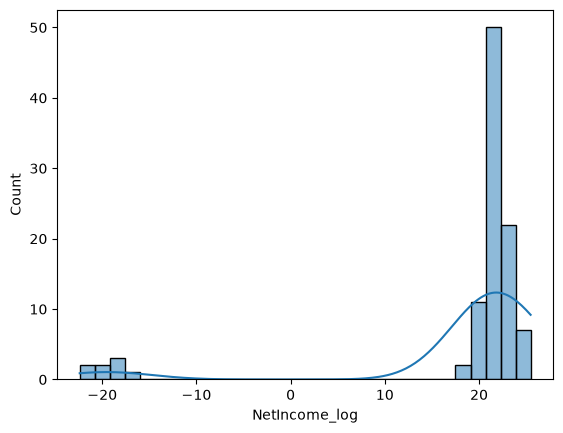

In [28]:
sns.histplot(df['NetIncome_log'], bins=30, kde=True)

<Axes: xlabel='EV_to_EBITDA_log', ylabel='Count'>

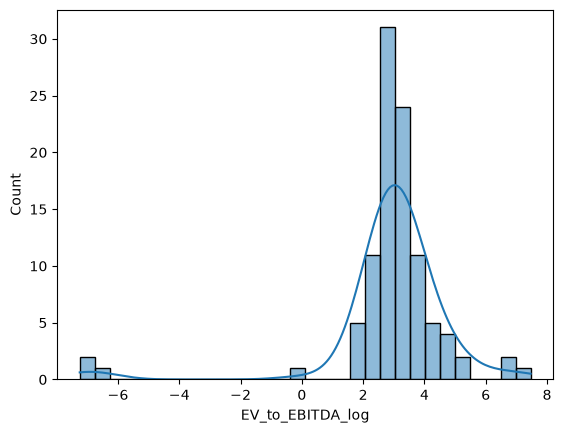

In [29]:
sns.histplot(df['EV_to_EBITDA_log'], bins=30, kde=True)

<Axes: xlabel='FreeCashFlow_log', ylabel='Count'>

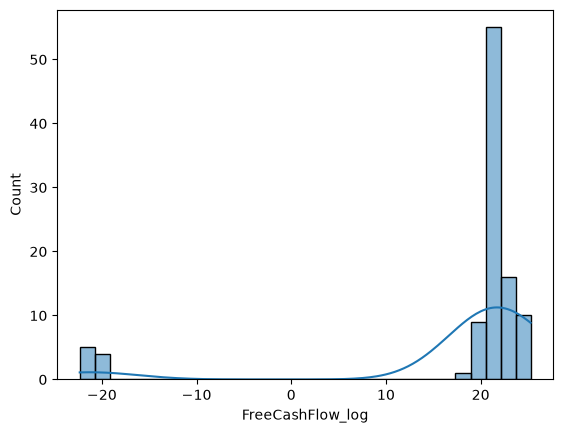

In [30]:
sns.histplot(df['FreeCashFlow_log'], bins=30, kde=True)

These two graphs show me that tehir are two main clusters of cash flow and Net income.  I wnat to perform clustering to see.

TotalDebt has extreme right skew, but after doing log transformation,  the distribution becomes more compact and roughly bell shaped for companies with debt. A small group of companies with debt close to zero shows on the graph of the log tranformation.

/var/folders/wx/28g1smx16bd3p9s2jjjwvwp00000gn/T/ipykernel_78150/697834869.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df,x='MarketCap_log',  hue='Sector',fill=True,alpha=0.3)


<Axes: xlabel='MarketCap_log', ylabel='Density'>

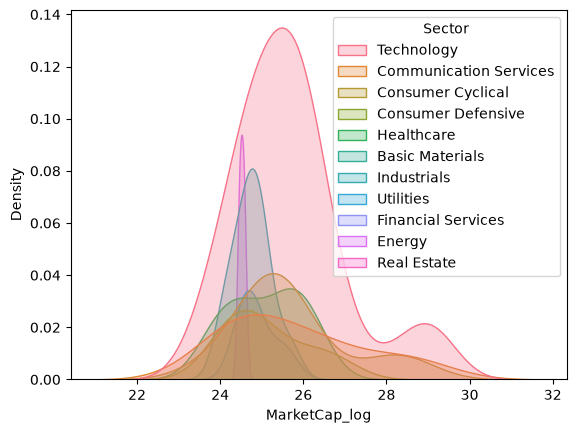

In [31]:
sns.kdeplot(data=df,x='MarketCap_log',  hue='Sector',fill=True,alpha=0.3)

/var/folders/wx/28g1smx16bd3p9s2jjjwvwp00000gn/T/ipykernel_78150/1870058907.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df,x='PE_log',  hue='Sector',fill=True,alpha=0.3)


<Axes: xlabel='PE_log', ylabel='Density'>

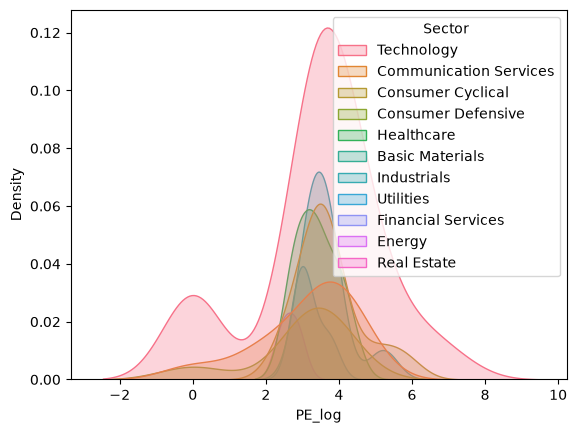

In [32]:
sns.kdeplot(data=df,x='PE_log',  hue='Sector',fill=True,alpha=0.3)

/var/folders/wx/28g1smx16bd3p9s2jjjwvwp00000gn/T/ipykernel_78150/3444525151.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df,x='Revenue_log',  hue='Sector',fill=True,alpha=0.3)


<Axes: xlabel='Revenue_log', ylabel='Density'>

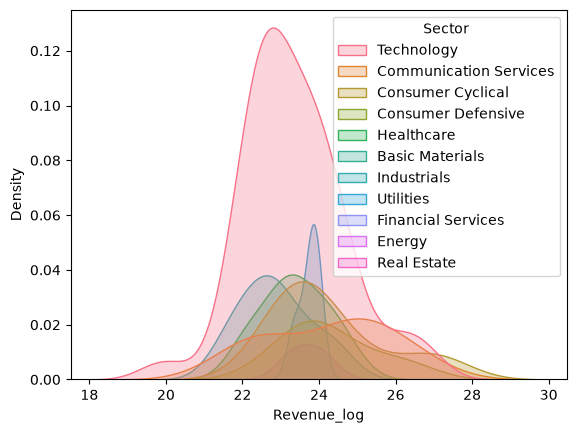

In [33]:
sns.kdeplot(data=df,x='Revenue_log',  hue='Sector',fill=True,alpha=0.3)

/var/folders/wx/28g1smx16bd3p9s2jjjwvwp00000gn/T/ipykernel_78150/666502450.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df,x='TotalDebt_log',  hue='Sector',fill=True,alpha=0.3)


<Axes: xlabel='TotalDebt_log', ylabel='Density'>

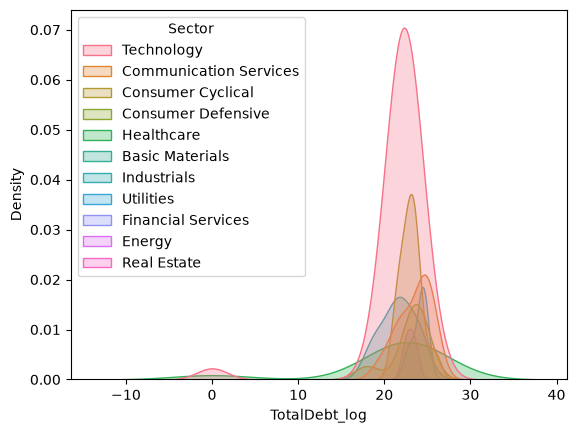

In [34]:
sns.kdeplot(data=df,x='TotalDebt_log',  hue='Sector',fill=True,alpha=0.3)

/var/folders/wx/28g1smx16bd3p9s2jjjwvwp00000gn/T/ipykernel_78150/3388130570.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df,x='Cash_log',  hue='Sector',fill=True,alpha=0.3)


<Axes: xlabel='Cash_log', ylabel='Density'>

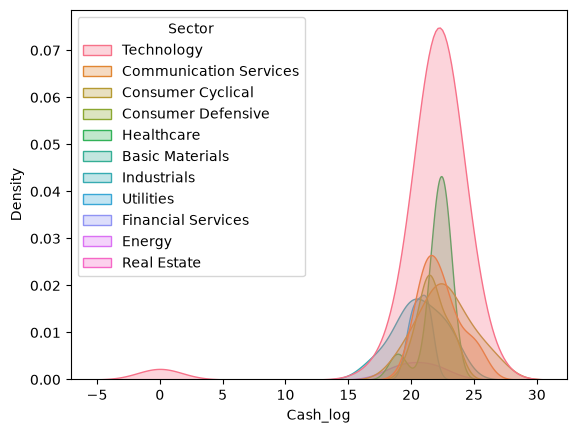

In [35]:
sns.kdeplot(data=df,x='Cash_log',  hue='Sector',fill=True,alpha=0.3)

/var/folders/wx/28g1smx16bd3p9s2jjjwvwp00000gn/T/ipykernel_78150/1386541360.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df,x='Price_to_Sales_log',  hue='Sector',fill=True,alpha=0.3)


<Axes: xlabel='Price_to_Sales_log', ylabel='Density'>

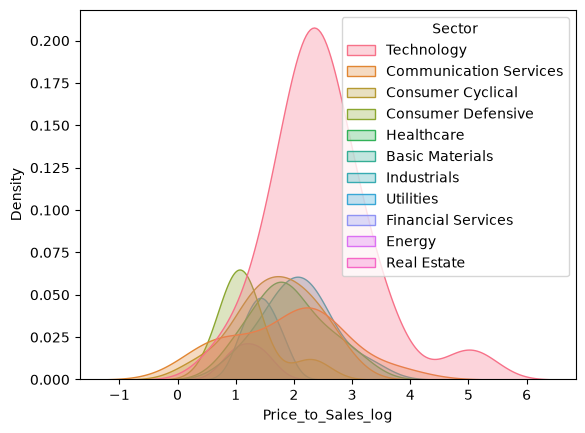

In [36]:
sns.kdeplot(data=df,x='Price_to_Sales_log',  hue='Sector',fill=True,alpha=0.3)

/var/folders/wx/28g1smx16bd3p9s2jjjwvwp00000gn/T/ipykernel_78150/3907386343.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df,x='NetIncome_log',  hue='Sector',fill=True,alpha=0.3)


<Axes: xlabel='NetIncome_log', ylabel='Density'>

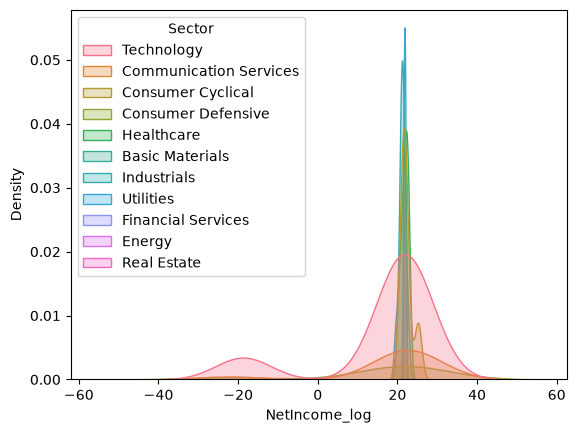

In [37]:
sns.kdeplot(data=df,x='NetIncome_log',  hue='Sector',fill=True,alpha=0.3)

/var/folders/wx/28g1smx16bd3p9s2jjjwvwp00000gn/T/ipykernel_78150/3577165253.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df,x='FreeCashFlow_log',  hue='Sector',fill=True,alpha=0.3)


<Axes: xlabel='FreeCashFlow_log', ylabel='Density'>

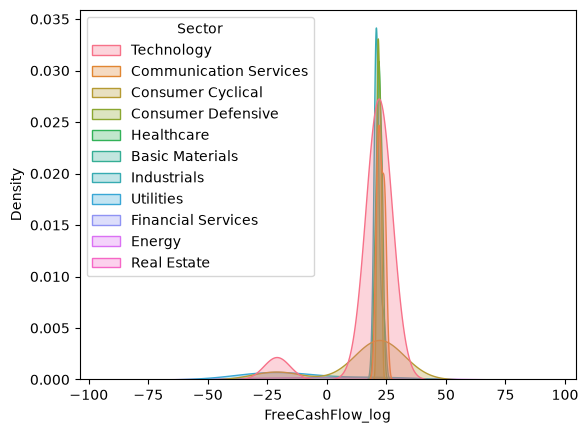

In [38]:
sns.kdeplot(data=df,x='FreeCashFlow_log',  hue='Sector',fill=True,alpha=0.3)

/var/folders/wx/28g1smx16bd3p9s2jjjwvwp00000gn/T/ipykernel_78150/3662447179.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df,x='EV_to_EBITDA_log',  hue='Sector',fill=True,alpha=0.3)


<Axes: xlabel='EV_to_EBITDA_log', ylabel='Density'>

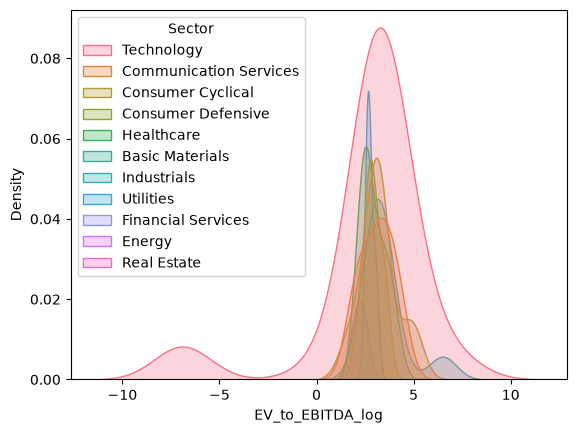

In [39]:
sns.kdeplot(data=df,x='EV_to_EBITDA_log',  hue='Sector',fill=True,alpha=0.3)

These graphs tell me that the technology sector is big, with more money in it because technology consistently appears as the highest and most dominant sector. This shows that big technology firms ( Apple, Microsoft, NVIDIA) represent a disproportionately large share of total market capitalization, produce industry-leading revenue and profitability, and command higher valuation multiples.

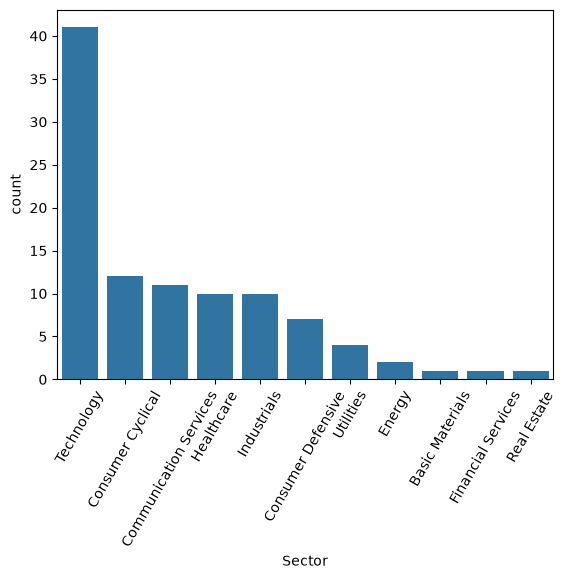

In [40]:
sns.countplot(data=df,x='Sector',order=df['Sector'].value_counts().index)
plt.xticks(rotation=60)
plt.show()

Finally I wanted to do a PCA anaylisis to see hoe sectors are similar in the different column values

In [41]:
features = [
    'MarketCap_log',
    'Revenue_log',
    'NetIncome_log',
    'FreeCashFlow_log',
    'TotalDebt_log',
    'Cash_log',
    'PE_log',
    'Price_to_Sales_log',
    'EV_to_EBITDA_log'
]


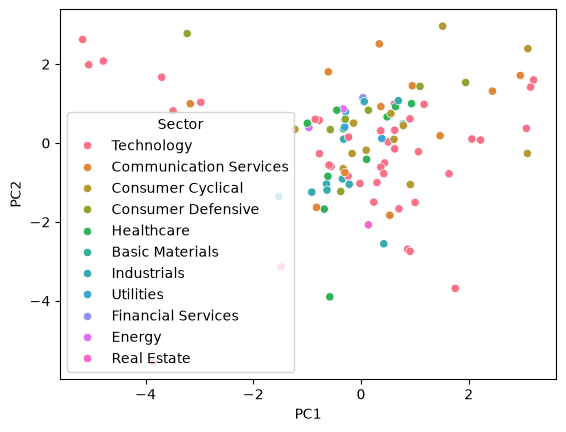

In [42]:
from sklearn.preprocessing import StandardScaler
# Import PCA if not already imported
from sklearn.decomposition import PCA
# to do the PCA I wanted to drop the companies with null values so I can get an understanding of the data without nulls
X = df[features].dropna()
# make a copy of df with just the non null rows 
pca_df = df.loc[X.index].copy()
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
pca_df['PC1'] = components[:, 0]
pca_df['PC2'] = components[:, 1]
sns.scatterplot(data=pca_df,x='PC1',y='PC2',hue='Sector')
plt.show()

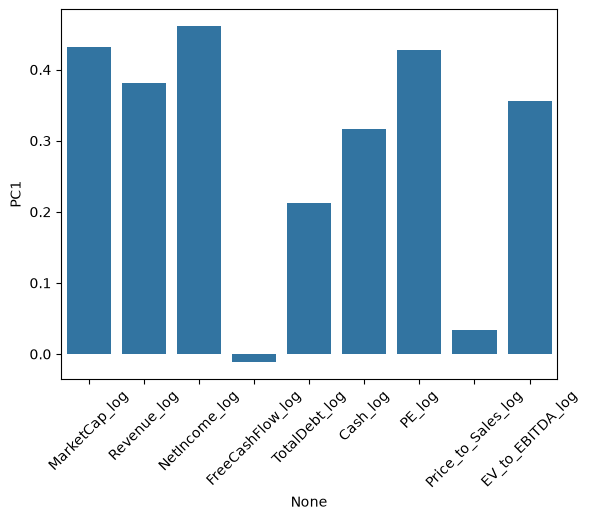

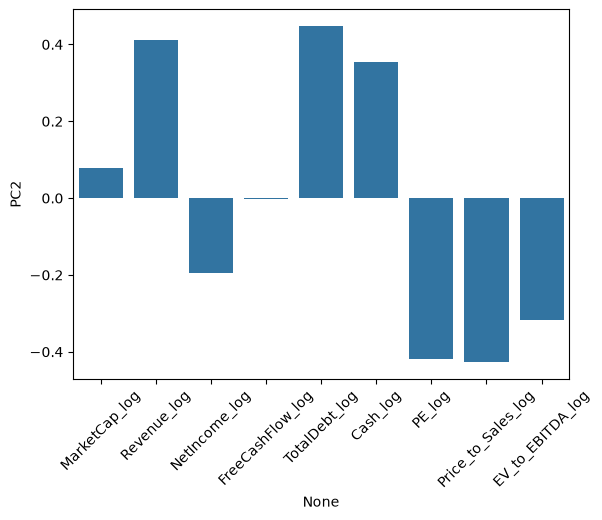

In [43]:
loadings = pd.DataFrame(pca.components_.T,index=features,columns=['PC1', 'PC2'])
sns.barplot(x=loadings.index, y=loadings['PC1'])
plt.xticks(rotation=45)
plt.show()
sns.barplot(x=loadings.index, y=loadings['PC2'])
plt.xticks(rotation=45)
plt.show()


The PCA loadings show that PC1 primarily represents company size and strength, with large impact from MarketCap, Revenue, Net Income, Cash, and Free Cash Flow. PC1 separates big, profitable, cash rich firms from smaller or financially weaker companies. In contrast, PC2 captures valuation and growth expectations, driven by high loadings from PE ratio, Price-to-Sales, and EV/EBITDA. Companies with high PC2 scores have high valuations and are growth companies, while those with low PC2 scores tend to be cheaper, more stable value stocks. This separates sectors such as Technology (large, high growth) from Utilities or Financial Services (smaller, lower growth).

This concludes my EDA, and going forward I really understand the variables and am ready for predictino and inference

INFERENCE - QUESTION:

Which firm characteristics are associated with being cheaper or more expensive relative to sector peers?

The sector-relative Z-score below is a descriptive measure of where each company sits compared with the other companies in this dataset. It is not a statistical test by itself.


Why this matters: Investors usually compare a company with similar companies, not with the whole market. Different sectors have different valuation levels, so the first step is to create sector-adjusted valuation scores. The inference step then asks whether fundamentals such as company size, revenue, profitability, free cash flow, debt, and cash are associated with those valuation differences.


Hypotheses for the inferential model:

H0: After controlling for sector, firm fundamentals are not associated with the sector-relative undervaluation score.

Ha: At least one firm fundamental is associated with the sector-relative undervaluation score after controlling for sector.


Descriptive scoring model: I first compare each company to others in the same sector instead of comparing it to the entire NASDAQ-100. I calculate typical EV/EBITDA and Price-to-Sales levels for each sector using market-cap weighting, then measure how each company compares with those benchmarks.

A higher `Undervalued_Z` means a company is cheaper than its sector peers based on this scoring rule. A lower `Undervalued_Z` means it trades at a premium. This Z-score is useful for ranking companies, but it is not uncertainty and does not prove that mispricing exists.


Model assumptions:

- Firms within the same sector are more comparable than firms across the entire market.
- EV/EBITDA and Price-to-Sales capture meaningful valuation information.
- Market-cap weighting creates sector benchmarks that reflect the larger firms investors often use as reference points.
- The later regression model assumes the relationship between logged fundamentals and the valuation score is approximately linear after sector controls.


Evaluation of uncertainty:

The Z-scores are descriptive rankings, not measures of statistical uncertainty. To add an actual inference step, I model each firm's `Undervalued_Z` as a function of logged fundamentals and sector indicators. In that regression, p-values and confidence intervals are used to evaluate which predictors have evidence of association with relative undervaluation.


Potential bias and limitations:

The dataset includes only NASDAQ-100 firms, so results should not be generalized to all public companies. Sector benchmarks are also created only from this dataset. The model does not include forward-looking growth rates, risk metrics, interest rates, or multi-year trends, so it should be treated as a screening framework rather than a complete investment decision model.


In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [45]:
#creating a copy of the df and keep the certain columns needed for the cross validation
df = df.copy()
cols = ['Ticker', 'Sector', 'Industry', 'EV_to_EBITDA', 'Price_to_Sales', 'MarketCap']
df = df[cols].dropna()

For the next part, I am buildiing a new df with the different sectors for with the averages and medians of EV/EBITDA and Price to Sales. I weight the averages by the marketcap, so that bigger companies have a bigger influence on the average.  First, create two columns in the df that weigh EV/EBITDA and Price to Sales by MarketCap.  These weighted columns make it so that the bigger companies have a bigger effect on the average.  Then, for the new data frame , grouping by sector, calculate the EV, PS medians and averages, and Market Cap, median and total of MC.  Then calculate the averages by dividing by MC Total.  This will calculate these for all sectors by using aggregate.  

In [46]:
#Compute the average valuation metric, but give larger companies more influence to the average 

df['EV_weighted'] = df['EV_to_EBITDA'] * df['MarketCap']
df['PS_weighted'] = df['Price_to_Sales'] * df['MarketCap']

summary_df = (
    df.groupby('Sector')
      .agg(
          EV_avg = ('EV_weighted', 'sum'),
          PS_avg = ('PS_weighted', 'sum'),
          EV_median = ('EV_to_EBITDA', 'median'),
          PS_median = ('Price_to_Sales', 'median'),
          MC_median = ('MarketCap', 'median'),
          MC_total  = ('MarketCap', 'sum')
      )
      .reset_index()
)

summary_df['EV_avg'] /= summary_df['MC_total']
summary_df['PS_avg'] /= summary_df['MC_total']
summary_df

,Sector,EV_avg,PS_avg,EV_median,PS_median,MC_median,MC_total
0,Basic Materials,17.869000,6.290680,17.8690,6.290680,2.091336e+11,209133649920
1,Communication Services,23.370460,9.681174,21.9400,8.115265,1.081078e+11,6235080056832
2,Consumer Cyclical,54.797433,7.300969,21.0545,4.631877,1.037106e+11,4814809630720
3,Consumer Defensive,23.809721,2.354150,15.3700,2.119204,6.804728e+10,875465103360
4,Energy,8.590902,2.379406,8.4815,2.415764,4.442826e+10,88856522752
5,Financial Services,10.529000,2.064188,10.5290,2.064188,6.665675e+10,66656751616
6,Healthcare,21.747519,8.262166,12.5295,4.888345,8.464795e+10,1065305630720
7,Industrials,83.449217,7.717733,26.0780,6.709142,5.518181e+10,618741471232
8,Real Estate,151.786000,11.318171,151.7860,11.318171,3.299813e+10,32998127616
9,Technology,40.024657,20.360510,20.9710,10.024806,1.323337e+11,19037092556800


In [47]:
# Now merge the summary df with the data so that every company will have its corresponding sectors summary data
df = df.merge(summary_df, on='Sector', how='left')

# Calulate the realive valyes compared ot it's sectors averages 
df['EV_relative'] = df['EV_to_EBITDA'] / df['EV_avg']
df['PS_relative'] = df['Price_to_Sales'] / df['PS_avg']


In [48]:
df['ValuationScore'] = df[['EV_relative', 'PS_relative']].mean(axis=1)
df['Undervalued_Z'] = ((1 / df['ValuationScore'] - (1 / df['ValuationScore']).mean()) / (1 / df['ValuationScore']).std())

The companies with the highest `Undervalued_Z` scores are cheapest relative to sector peers under this scoring rule. The companies with the lowest values are trading at the largest premiums relative to sector peers.


In [49]:
# Undervalued top 10 companies 
df.sort_values('Undervalued_Z', ascending=False).head(10)

,Ticker,Sector,Industry,EV_to_EBITDA,Price_to_Sales,MarketCap,EV_weighted,PS_weighted,EV_avg,PS_avg,EV_median,PS_median,MC_median,MC_total,EV_relative,PS_relative,ValuationScore,Undervalued_Z
24,PDD,Consumer Cyclical,Internet Retail,4.029,0.464272,190175854592,7.662185e+11,8.829334e+10,54.797433,7.300969,21.0545,4.631877,1.037106e+11,4814809630720,0.073525,0.063590,0.068558,6.563254
88,CTSH,Technology,Information Technology Services,8.815,1.617814,33142548480,2.921516e+11,5.361849e+10,40.024657,20.360510,20.9710,10.024806,1.323337e+11,19037092556800,0.220239,0.079458,0.149849,2.456920
43,CMCSA,Communication Services,Telecom Services,5.248,0.870545,108107808768,5.673498e+11,9.411276e+10,23.370460,9.681174,21.9400,8.115265,1.081078e+11,6235080056832,0.224557,0.089921,0.157239,2.294149
84,CHTR,Communication Services,Telecom Services,6.006,0.604026,33355520000,2.003333e+11,2.014760e+10,23.370460,9.681174,21.9400,8.115265,1.081078e+11,6235080056832,0.256991,0.062392,0.159691,2.243469
99,GFS,Technology,Semiconductors,8.430,2.864893,19601598464,1.652415e+11,5.615649e+10,40.024657,20.360510,20.9710,10.024806,1.323337e+11,19037092556800,0.210620,0.140708,0.175664,1.947982
98,CDW,Technology,Information Technology Services,13.180,0.947449,20728567808,2.732025e+11,1.963926e+10,40.024657,20.360510,20.9710,10.024806,1.323337e+11,19037092556800,0.329297,0.046534,0.187915,1.755383
96,LULU,Consumer Cyclical,Apparel Retail,7.302,1.937725,21129029632,1.542842e+11,4.094226e+10,54.797433,7.300969,21.0545,4.631877,1.037106e+11,4814809630720,0.133254,0.265407,0.199331,1.597233
67,PCAR,Industrials,Farm & Heavy Construction Machinery,16.206,1.780752,52588273664,8.522456e+11,9.364666e+10,83.449217,7.717733,26.0780,6.709142,5.518181e+10,618741471232,0.194202,0.230735,0.212469,1.436249
97,ON,Technology,Semiconductors,12.089,3.241087,20739069952,2.507146e+11,6.721714e+10,40.024657,20.360510,20.9710,10.024806,1.323337e+11,19037092556800,0.302039,0.159185,0.230612,1.244088
23,INTU,Technology,Software - Application,0.000,10.113584,190448910336,0.000000e+00,1.926121e+12,40.024657,20.360510,20.9710,10.024806,1.323337e+11,19037092556800,0.000000,0.496726,0.248363,1.083255


In [50]:
#Overvalued companies top 10 
df.sort_values('Undervalued_Z').head(10)


,Ticker,Sector,Industry,EV_to_EBITDA,Price_to_Sales,MarketCap,EV_weighted,PS_weighted,EV_avg,PS_avg,EV_median,PS_median,MC_median,MC_total,EV_relative,PS_relative,ValuationScore,Undervalued_Z
71,ZS,Technology,Software - Infrastructure,-634.689,19.127934,51131162624,-3.245239e+13,9.780335e+11,40.024657,20.360510,20.971,10.024806,1.323337e+11,19037092556800,-15.857450,0.939462,-7.458994,-1.075791
81,TEAM,Technology,Software - Application,-1077.630,8.208906,42811944960,-4.613544e+13,3.514392e+11,40.024657,20.360510,20.971,10.024806,1.323337e+11,19037092556800,-26.924153,0.403178,-13.260488,-1.045352
37,CRWD,Technology,Software - Infrastructure,-1403.178,30.483887,132333666304,-1.856877e+14,4.034045e+12,40.024657,20.360510,20.971,10.024806,1.323337e+11,19037092556800,-35.057839,1.497206,-16.780316,-1.037143
66,DDOG,Technology,Software - Application,1743.330,18.092552,54568148992,9.513029e+13,9.872771e+11,40.024657,20.360510,20.971,10.024806,1.323337e+11,19037092556800,43.556401,0.888610,22.222505,-0.982865
9,PLTR,Technology,Software - Infrastructure,723.226,127.305480,438005596160,3.167770e+14,5.576051e+13,40.024657,20.360510,20.971,10.024806,1.323337e+11,19037092556800,18.069511,6.252568,12.161040,-0.963544
64,AXON,Industrials,Aerospace & Defense,663.503,24.157713,57775341568,3.833411e+13,1.395720e+12,83.449217,7.717733,26.078,6.709142,5.518181e+10,618741471232,7.950979,3.130157,5.540568,-0.912554
48,MSTR,Technology,Software - Application,13.934,179.522870,82997370880,1.156485e+12,1.489993e+13,40.024657,20.360510,20.971,10.024806,1.323337e+11,19037092556800,0.348135,8.817209,4.582672,-0.892976
28,ARM,Technology,Semiconductors,189.255,43.871677,180795179008,3.421639e+13,7.931788e+12,40.024657,20.360510,20.971,10.024806,1.323337e+11,19037092556800,4.728460,2.154744,3.441602,-0.855431
18,APP,Communication Services,Advertising Agencies,61.808,36.551050,209714954240,1.296206e+13,7.665302e+12,23.370460,9.681174,21.940,8.115265,1.081078e+11,6235080056832,2.644706,3.775477,3.210092,-0.844556
56,MNST,Consumer Defensive,Beverages - Non-Alcoholic,28.933,8.884427,68047282176,1.968812e+12,6.045611e+11,23.809721,2.354150,15.370,2.119204,6.804728e+10,875465103360,1.215176,3.773943,2.494559,-0.798186


The ranking results show meaningful variation in relative valuation across the NASDAQ-100. However, that variation alone does not prove a statistical hypothesis because any dataset with variation will produce higher and lower Z-scores. The table is best interpreted as a screening tool that identifies which firms deserve deeper investigation.


To make the inference section stronger, I now model the descriptive `Undervalued_Z` score as a function of company fundamentals. This evaluates whether differences in firm size, revenue, profitability, free cash flow, debt, cash, and sector are associated with the relative valuation score.


In [51]:
import statsmodels.api as sm

fundamentals = pd.read_csv("../data/raw/nasdaq100_fundamentals.csv")

inference_df = df[["Ticker", "Sector", "Undervalued_Z"]].merge(
    fundamentals[[
        "Ticker",
        "MarketCap",
        "Revenue",
        "NetIncome",
        "FreeCashFlow",
        "TotalDebt",
        "Cash",
    ]],
    on="Ticker",
    how="left",
)

for col in ["MarketCap", "Revenue", "TotalDebt", "Cash"]:
    inference_df[f"{col}_log"] = np.log1p(inference_df[col])

for col in ["NetIncome", "FreeCashFlow"]:
    inference_df[f"{col}_log"] = np.sign(inference_df[col]) * np.log1p(abs(inference_df[col]))

inference_features = [
    "MarketCap_log",
    "Revenue_log",
    "NetIncome_log",
    "FreeCashFlow_log",
    "TotalDebt_log",
    "Cash_log",
]

model_df = inference_df[["Undervalued_Z", "Sector"] + inference_features].replace(
    [np.inf, -np.inf], np.nan
).dropna()

X = pd.get_dummies(model_df[["Sector"] + inference_features], drop_first=True, dtype=float)
X = sm.add_constant(X)
y = model_df["Undervalued_Z"]

ols_model = sm.OLS(y, X).fit(cov_type="HC3")
ols_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          Undervalued_Z   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.634
Method:                 Least Squares   F-statistic:                     10.60
Date:                Mon, 06 Jul 2026   Prob (F-statistic):           5.46e-14
Time:                        14:05:06   Log-Likelihood:                -81.369
No. Observations:                  99   AIC:                             196.7
Df Residuals:                      82   BIC:                             240.9
Df Model:                          16                                         
Covariance Type:                  HC3                                         
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                             1.0378      2.350      0.442      0.659      -3.569       5.644
MarketCap_log                    -0.9136      0.209     -4.368      0.000      -1.324      -0.504
Revenue_log                       0.8784      0.177      4.955      0.000       0.531       1.226
NetIncome_log                     0.0095      0.006      1.518      0.129      -0.003       0.022
FreeCashFlow_log                  0.0069      0.006      1.072      0.284      -0.006       0.020
TotalDebt_log                    -0.0309      0.036     -0.846      0.397      -0.102       0.041
Cash_log                          0.0620      0.138      0.450      0.653      -0.208       0.332
Sector_Communication Services     0.4019      1.932      0.208      0.835      -3.385       4.188
Sector_Consumer Cyclical          0.6868      1.956      0.351      0.726      -3.147       4.521
Sector_Consumer Defensive        -0.6975      1.941     -0.359      0.719      -4.501       3.106
Sector_Energy                    -0.6986      2.081     -0.336      0.737      -4.778       3.381
Sector_Financial Services        -1.0761      1.957     -0.550      0.583      -4.913       2.760
Sector_Healthcare                 0.0918      1.932      0.048      0.962      -3.694       3.878
Sector_Industrials                0.5553      1.930      0.288      0.774      -3.227       4.337
Sector_Real Estate                0.4284      2.918      0.147      0.883      -5.290       6.147
Sector_Technology                 0.9176      1.927      0.476      0.634      -2.860       4.695
Sector_Utilities                 -0.2175      1.943     -0.112      0.911      -4.026       3.591
==============================================================================
Omnibus:                      109.089   Durbin-Watson:                   2.206
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1890.728
Skew:                           3.578   Prob(JB):                         0.00
Kurtosis:                      23.178   Cond. No.                     1.94e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 1.94e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

This regression is the statistical inference step. The dependent variable is still the sector-relative valuation score, but now the question is why some firms receive higher or lower scores. The sector dummy variables control for baseline differences between sectors, while the logged financial variables test whether company fundamentals are associated with relative undervaluation.

I use HC3 robust standard errors because the companies are very different sizes and the variance is unlikely to be constant across firms. The p-values should be interpreted carefully because the sample is small and limited to NASDAQ-100 companies.


In [52]:
coef_table = pd.DataFrame({
    "coefficient": ols_model.params,
    "p_value": ols_model.pvalues,
    "conf_low": ols_model.conf_int()[0],
    "conf_high": ols_model.conf_int()[1],
})

coef_table.loc[inference_features].sort_values("p_value")


,coefficient,p_value,conf_low,conf_high
Revenue_log,0.878359,7.248279e-07,0.530893,1.225825
MarketCap_log,-0.913624,1.254736e-05,-1.323590,-0.503659
NetIncome_log,0.009517,1.289841e-01,-0.002770,0.021804
FreeCashFlow_log,0.006920,2.835240e-01,-0.005726,0.019566
TotalDebt_log,-0.030870,3.974360e-01,-0.102369,0.040630
Cash_log,0.062015,6.525381e-01,-0.207948,0.331978


The coefficient table provides a more appropriate inference interpretation than the earlier Z-score discussion. A statistically meaningful coefficient would suggest that a firm characteristic is associated with relative under- or over-valuation in this sample, after accounting for sector. A non-significant coefficient would mean I do not have enough evidence in this dataset to claim that predictor explains the valuation score.

This still does not prove that a stock is truly mispriced. It shows which observable fundamentals help explain the scoring model and which companies remain interesting candidates for deeper financial research.


PREDICTION

The valuation of stocks tend to fluctuate over time, but extreme values often move back toward typical levels. This prediction section is going to build off the inference section by testing whether firms that are overvalued, or priced far above their sector are able to produce the earnings that they need to stay highly valued in the next 1, 3 and 5 years.  This will allow us to see if a company is overvaleued for good reason or if it is unattainable to to produce and they just have a value of a stock that is beyond what is possible. So the question I want to answer is: Which stocks require the most unrealistic growth to justify their price?

The dependent variable is the revenue growth rate over one, three, and five years required for a firm’s valuation to revert to its sector’s average Price-to-Sales ratio.

In [53]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

target_col = 'Undervalued_Z'

feature_cols = [
    'EV_to_EBITDA',
    'Price_to_Sales',
    'MarketCap',
    'EV_avg',
    'PS_avg'
]

df_pred = df[feature_cols + [target_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()

X = df_pred[feature_cols]
y = df_pred[target_col]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

In [54]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


In [55]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def eval_regressor(model, X_tr, y_tr, X_v, y_v, name="Model"):
    y_tr_pred = model.predict(X_tr)
    y_v_pred  = model.predict(X_v)

    rmse_tr = np.sqrt(mean_squared_error(y_tr, y_tr_pred))
    rmse_v  = np.sqrt(mean_squared_error(y_v, y_v_pred))

    mae_tr = mean_absolute_error(y_tr, y_tr_pred)
    mae_v  = mean_absolute_error(y_v, y_v_pred)

    r2_tr = r2_score(y_tr, y_tr_pred)
    r2_v  = r2_score(y_v, y_v_pred)

    print(f"\n{name}")
    print(f"Train RMSE: {rmse_tr:.3f}   Val RMSE: {rmse_v:.3f}")
    print(f"Train MAE : {mae_tr:.3f}   Val MAE : {mae_v:.3f}")
    print(f"Train R^2 : {r2_tr:.3f}   Val R^2 : {r2_v:.3f}")


The first model I tried, was a simple linear regression, the results showed that it was not a good fit for the data, as it produced  negative R². This shows that valuation growth depends on nonlinear factors and cannot be accuratley modeled by a simple linear relationship.

In [56]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

eval_regressor(lin_reg,X_train_scaled, y_train,X_val_scaled,   y_val, name="Linear Regression")



Linear Regression
Train RMSE: 0.727   Val RMSE: 1.656
Train MAE : 0.539   Val MAE : 0.904
Train R^2 : 0.173   Val R^2 : -0.018


I then tried Ridge Regression which is a linear model but controls the coefficients. The ridge model gives a linear regression but with shrinking unstable coefficients, improving generalization, and reducing sensitivity to noise.  I wanted to check by doing a ridge model to really make sure no linear model will fit the data, and it did not.  The validation R² value was negative again, and so this reinforces that the relationship between valuation ratios and implied growth is not linear.

In [57]:
#for ridge, you test and find the best alpha value 
ridge = Ridge()
param_grid_ridge = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

ridge_cv = GridSearchCV(ridge,param_grid_ridge,cv=5,scoring='neg_root_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_train)

print("Best Ridge alpha:", ridge_cv.best_params_['alpha'])

ridge_best = ridge_cv.best_estimator_

eval_regressor(
    ridge_best,
    X_train_scaled, y_train,
    X_val_scaled,   y_val,
    name="Ridge Regression"
)


Best Ridge alpha: 10.0

Ridge Regression
Train RMSE: 0.730   Val RMSE: 1.658
Train MAE : 0.542   Val MAE : 0.916
Train R^2 : 0.167   Val R^2 : -0.020


The next model I tried is a random forest regression.  This breaks the data up by decision trees and makes predictions based on those splits.  This will handle nonlinear data and account for sector differences.  The random Forest regression gave a R² of .48 which is way better than the first two models, so we know that we are on the right track.  There is an issue though, when looking at the training and validation sets, the model is overfitting.  There is a big gap between the Training error and the validation error.  This tells us that altough this model learns the data well, it also is learning a lot of noise as well, making it very prone to overfitting data.  

In [58]:
rf = RandomForestRegressor(random_state=42)

param_grid_rf = {'n_estimators': [200, 500],'max_depth': [None, 5, 10],'min_samples_split': [2, 5],}

rf_cv = GridSearchCV(rf,param_grid_rf,cv=5,scoring='neg_root_mean_squared_error',n_jobs=-1)
rf_cv.fit(X_train, y_train)

print("Best RF params:", rf_cv.best_params_)

rf_best = rf_cv.best_estimator_

eval_regressor(rf_best,X_train, y_train,X_val,   y_val,name="Random Forest")


Best RF params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Random Forest
Train RMSE: 0.167   Val RMSE: 1.176
Train MAE : 0.120   Val MAE : 0.579
Train R^2 : 0.957   Val R^2 : 0.487


I then did rersearch on a model that would be able to learn and fit this data accuratley without so much overfitting.  I came upon Gradient Boosting Regression.  In an IBM article, they explained it as "a machine learning technique that combines multiple weak prediction models into a single ensemble. These weak models are typically decision trees, which are trained sequentially to minimize errors and improve accuracy. By combining multiple decision tree regressors or decision tree classifiers, gradient boosting can effectively capture complex relationships between features."  I thought this would fit my data well, as the decision trees were the best result we have had so far, so I imported the GradientBoostingRegressor from sklearn and tried fitting it with my data.  This gave the best results yet, with lower error and higher explanatory power.  Validation R² tells us the model explains approximatley 51% of variance.  I am hapy with this as that is strong for noisy cross-sectional financial data.  The difference in the R² values tells us this model is still overfitting to the training data.  The model fits training data extremely well but generalizes with moderate success.  In this case, its performance on new data is still strong for financial data, which is naturally unpredictable.  

In [59]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

eval_regressor(gbr, X_train, y_train, X_val, y_val, name="Gradient Boosting")



Gradient Boosting
Train RMSE: 0.028   Val RMSE: 1.151
Train MAE : 0.020   Val MAE : 0.509
Train R^2 : 0.999   Val R^2 : 0.508


I decided to choose Gradient Boosting Regressor as the best model for my data.  I then did the test on the test data, and the results wee good.  The validation R² value is .67 which is very good.  Even though the model fits the training data very well, it still predicts new data accurately, which means it learned real patterns instead of just memorizing.

In [60]:
eval_regressor(gbr, X_train, y_train, X_test, y_test, name="Gradient Boosting (Final Test)")



Gradient Boosting (Final Test)
Train RMSE: 0.028   Val RMSE: 0.170
Train MAE : 0.020   Val MAE : 0.122
Train R^2 : 0.999   Val R^2 : 0.670


In [61]:
import numpy as np

for t in [1, 3, 5]:
    df[f'Growth_Req_{t}yr'] = (df['Price_to_Sales'] / df['PS_avg'])**(1/t) - 1

top10 = df.sort_values('Growth_Req_3yr', ascending=False).head(10)
X_top10 = top10[X.columns] 

top10[['Ticker', 'Sector','Growth_Req_1yr','Growth_Req_3yr','Growth_Req_5yr']].round(3)


,Ticker,Sector,Growth_Req_1yr,Growth_Req_3yr,Growth_Req_5yr
48,MSTR,Technology,7.817,1.066,0.545
9,PLTR,Technology,5.253,0.842,0.443
18,APP,Communication Services,2.775,0.557,0.304
56,MNST,Consumer Defensive,2.774,0.557,0.304
64,AXON,Industrials,2.130,0.463,0.256
21,ISRG,Healthcare,1.440,0.346,0.195
28,ARM,Technology,1.155,0.292,0.166
7,TSLA,Consumer Cyclical,1.066,0.274,0.156
70,IDXX,Healthcare,0.537,0.154,0.090
37,CRWD,Technology,0.497,0.144,0.084


The Growth_Req_1yr is the Growth needed immediately, Growth_Req_3yr	is the growth needed each year for the next 3 years,
Growth_Req_5yr is the growth needed each year for the next 5 years.

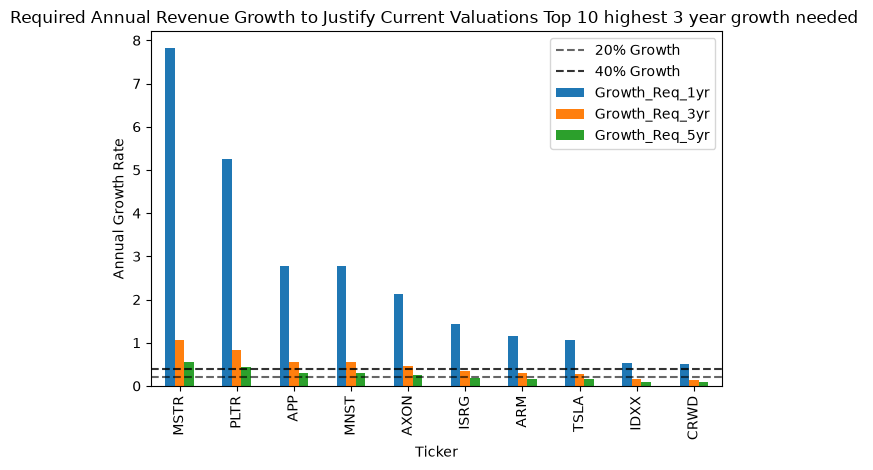

In [62]:
import matplotlib.pyplot as plt

top10 = top10.sort_values("Growth_Req_3yr", ascending=False)
top10.set_index("Ticker")[["Growth_Req_1yr","Growth_Req_3yr","Growth_Req_5yr"]].plot(kind="bar")

plt.axhline(0.20, linestyle="--", color="black", alpha=0.6, label="20% Growth")
plt.axhline(0.40, linestyle="--", color="black", alpha=0.8, label="40% Growth")

plt.title("Required Annual Revenue Growth to Justify Current Valuations Top 10 highest 3 year growth needed ")
plt.ylabel("Annual Growth Rate")
plt.legend()
plt.tight_layout()
plt.show()


Firms at the top of the growth requirement ranking are priced under very optimistic assumptions. Several would require sustained growth rates higher than historical norms in order to justify their current valuations. This shows that these stocks have high risk if performance does not meet expectations.

This model is useful because it turns valuation multiples into growth expectations, allowing investors to evaluate how realistic current stock prices are. Instead of labeling companies as simply “overvalued” or “undervalued,” the model quantifies how fast a company’s revenue must grow for its valuation to be reasonable relative to other companies in it's sector. This model can support decision making. Investors can use the model as a screening tool to find firms priced with unrealistic assumptions and assess downside risk. It can also help compare companies across sectors' valuations in the same unit growth rate. Analysts can also use it to test whether future performance expectations are plausible and find cases where stock prices depend on almost perfect execution by the comapny. This model isn’t trying to predict future revenue or stock prices. It’s more of a check on valuation that shows what the market is assuming about a company’s growth. It is useful for spotting optimistic stock pricing and understanding risk, not making forecasts.

Overall, this project gave insight into the leading stocks in the market, and helped give insight into what makes a stock valuable and what helps investors make financial decisions.  My brother is a financial advsior and he helped me with what questions he would want answered about this data.  This was very exciting because I was able to answer real questions that he has in his work in finance day to day.  